## ANN for classification, example 1, mobile phone price class classification

**This is experimentation with Keras Tuner, see details below.**

In [13]:
# you'll need Keras Tuner later in this notebook:

# pip install keras-tuner
# pip install tensorboard

In [14]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

# encoders
from sklearn.preprocessing import LabelEncoder

# classification metrics
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# THIS OPTIONAL (but recommended!), so you can comment out the following
# code if you don't wish to remove randomness
# you might want to lock down the random seed throughout,
# so you get the same results every time (given that nothing has changed in the data itself)

import random
import os

# THIS IS OUR RANDOM SEED, change if you want
SEED = 9876543

# step 1: Lock down Python's built-in random module seed
random.seed(SEED)

# step 2: Lock down NumPy's random seed
np.random.seed(SEED)

# step 3: Lock down TensorFlow seed
tf.random.set_seed(SEED)

# step 4: set environment variables (affects some backend randmoness in TF/Keras)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# step 5 (optional): control the inter-op and intra-op parallelism for determinism
# (this can slightly slow down training, but improves reproducibility)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

In [15]:
# load the data
df = pd.read_csv("mobilepricerangeclass.csv")

In [16]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [17]:
# let's remove some of the variables that are probably not extremely important in this dataset
# NOTE! this was just a quick decision to try optimization, this is just an example
# on how you can use correlation matrix, SelectKBest etc. to choose your variables
removables = ['touch_screen', 'dual_sim', "clock_speed", "m_dep", "three_g", "four_g", "wifi", "blue"]
df = df.drop(removables, axis=1)

In [18]:
# this is technically completely optional
# but it's nicer to study the results when we have actual names for the output
# instead of just 0, 1, 2, 3 etc.

# let's assign actual names for the price classes
# so we have nicer metrics and results later (after training the model)
df['price_range'] = df['price_range'].replace({
    0: "1: Cheap",
    1: "2: Avg-",
    2: "3: Avg+",
    3: "4: Expensive"
})

## X/y -split

**NOTE! Due to cross entropy, we have to modify the y-variable further! See details below**

In [19]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("price_range", axis=1)

# have only the target variable here (dependent variable)
y_temp = df['price_range']

# since we are doing classification, we have to process our target values with an encoder
# and convert them into a categorical TensorFlow/Keras -format
le = LabelEncoder()
y_enc = le.fit_transform(y_temp)

# convert the label into matrix form
y = tf.keras.utils.to_categorical(y_enc)

# save the categories into a helper list for later purposes
categories = list(le.classes_)
categories

['1: Cheap', '2: Avg-', '3: Avg+', '4: Expensive']

### train/test/validation -split

In [20]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.35)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

### USE KERAS TUNER TO FIND OPTIMAL PARAMETERS FOR THE NEURAL NETWORK

In [ ]:
# pip install keras-tuner
# pip install tensorboard
import keras_tuner

# Keras Tuner needs the neural network creation code in a separate function
def build_model(hp):
    # initialize the neural network (Sequential)
    model = keras.Sequential()

    # first layer, batch normalization + input shape, same as in typical neural network
    model.add(layers.BatchNormalization(input_shape=(len(X.columns),)))

    # add the actual first Dense-layer including the regularizer
    model.add(
        layers.Dense(
            # Tune number of units.
            units=hp.Int("units_0", min_value=4, max_value=96, step=4),
            # Tune the activation function to use.
            activation=hp.Choice("activation", ["relu"]),
            # Tune the regularization feature as well
            kernel_regularizer=keras.regularizers.l1(hp.Float("l1", min_value=0.025, max_value=0.35, sampling="log"))
        )
    )
    # Tune whether to use dropout.
    if hp.Boolean("dropout"):
        model.add(layers.Dropout(
            rate=hp.Float("rate", min_value=0.1, max_value=0.5, step=0.025)
            ))

    # try additional layers, 1-3 extra layers
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(
            layers.Dense(
                # Tune number of units for each
                units=hp.Int(f"units_{i + 1}", min_value=8, max_value=96, step=4),
                activation=hp.Choice("activation", ["relu"]),
            )
        )

    # output layer, use the amount of target categories for nodes, 
    # softmax for activation function
    model.add(layers.Dense(len(categories), activation="softmax"))

    # Define the optimizer learning rate as a hyperparameter.
    learning_rate = hp.Float("lr", min_value=1e-5, max_value=1e-1, sampling="log")

    # compile the test neural network for tuning
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

# build the model + use RandomSearch to actually search the best options for our neural network
build_model(keras_tuner.HyperParameters())

# use val_accuracy as the objective (we wish to maximize this)
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=3,
    overwrite=True,
    directory="optimizations1",
    project_name="classification1test",
)

# start searching
tuner.search(X_train, y_train, epochs=200, validation_data=(X_val, y_val))

c:\Users\tuomas.valtanen\deeplearning2026lectures\DeepLearningAutumn2026\.venv\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# print out the result and suggestions
tuner.results_summary()

In [ ]:
# get the top model
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()

### Create the neural network structure

**NOTE: you can use all the same callback features as in regression: ModelCheckpoint, EarlyStop, ReduceLRONPlateau, Dropout-layers etc...**

In [24]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# needed imports for ModelCheckpoint etc. callbacks
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# for EarlyStop/ReduceLROnPlateau, see materials and Moodle
# for examples on how to use and when to use (usually more useful with classification)

# create a model checkpoint to a file, and only save the best one
mc = ModelCheckpoint('best_model_classification1_kt.keras', monitor='val_accuracy', mode='max', save_best_only=True)

# combine all active callbacks into a list
# have only those you need, for example only ModelCheckpoint
callback_list = [mc]

# Trial 0 summary
# Hyperparameters:
# units_0: 96
# activation: relu
# l1: 0.027275375560326137
# dropout: False
# num_layers: 1
# units_1: 88
# lr: 0.05759030042816015
# Score: 0.9780952533086141

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape

# output layer in classification depends on the amounts of
# unique output options in the target variable
model = keras.Sequential(
    [
        layers.BatchNormalization(input_shape=(variable_amount,)),
        layers.Dense(96, activation="relu", kernel_regularizer=keras.regularizers.l1(l1=0.027275375560326137)),
        layers.Dense(88, activation="relu"),
        layers.Dense(len(categories), activation="softmax")
    ]
)

# save the learning rate to a variable for easier changes
optimal_lr = 0.05759030042816015

# select the optimizer and loss function
# for classification, we use categorical crossentropy this time for loss-function
# we also wish to measure the accuracy of our model in the metrics
model.compile(optimizer=keras.optimizers.Adam(learning_rate=optimal_lr), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_4           │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 96)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 88)             │         8,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           356 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,188 (39.80 KB)

 Trainable params: 10,164 (39.70 KB)

 Non-trainable params: 24 (96.00 B)

**Train the next**

In [25]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=300, validation_data=(X_val, y_val), callbacks=callback_list)

Epoch 1/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6092 - loss: 1.8811 - val_accuracy: 0.2743 - val_loss: 7.1821
Epoch 2/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7277 - loss: 1.1652 - val_accuracy: 0.2657 - val_loss: 6.8468
Epoch 3/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7954 - loss: 0.8467 - val_accuracy: 0.2886 - val_loss: 4.1779
Epoch 4/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7869 - loss: 0.7786 - val_accuracy: 0.4400 - val_loss: 2.0648
Epoch 5/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8031 - loss: 0.7489 - val_accuracy: 0.6086 - val_loss: 1.2918
Epoch 6/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8054 - loss: 0.7424 - val_accuracy: 0.7171 - val_loss: 0.9192
Epoch 7/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8031 - loss: 0.7486 - val_accuracy: 0.7943 - val_loss: 0.7696
Epoch 8/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8015 - loss: 0.7507 - val_accuracy: 0.8114 - v

### Error and performance metrics

<Axes: >

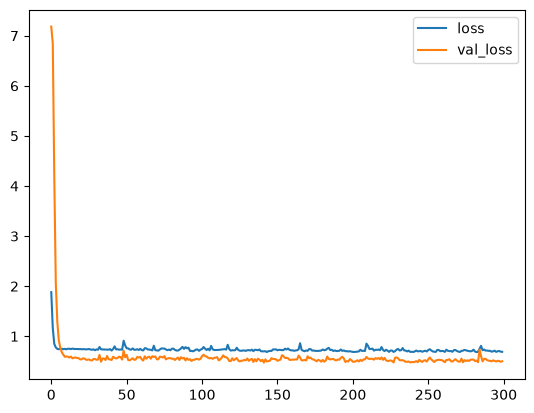

In [26]:
loss_df = pd.DataFrame(model.history.history)
loss_df[['loss', 'val_loss']].plot()

# the model seems to learn fairly well according to loos
# not overfitting, but there's a slight room for improvement

<Axes: >

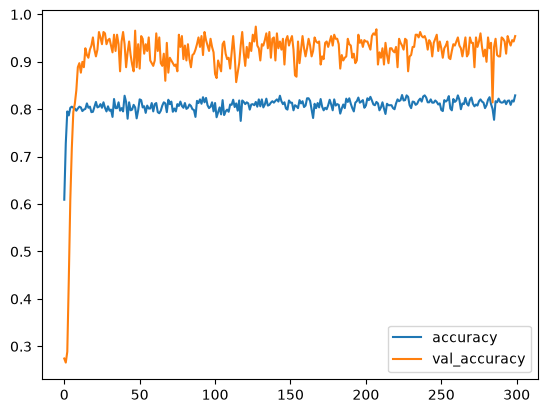

In [27]:
# validation accuracy is fairly high (which is the result from the validation dataset)
# training accuracy is a bit low, but val_accuracy is usually more important to be maximized
# training accuracy being low can imply there's toom for improvement still in the neural network
loss_df[['accuracy', 'val_accuracy']].plot()

In [28]:
# compare the final model loss/evaluation values
# the values should match roughly
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

# in classification we compare the loss and accuracy values

Test data evaluation:
[0.5149631500244141, 0.9314285516738892]

Train data evaluation:
[0.5258299112319946, 0.9200000166893005]


In [29]:
# get predictions and convert with argmax() to get the categories
# instead of RAW probabilites
test_predictions = model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)

# convert also y-test values with argmax
y_test = np.argmax(y_test, axis=1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<Axes: >

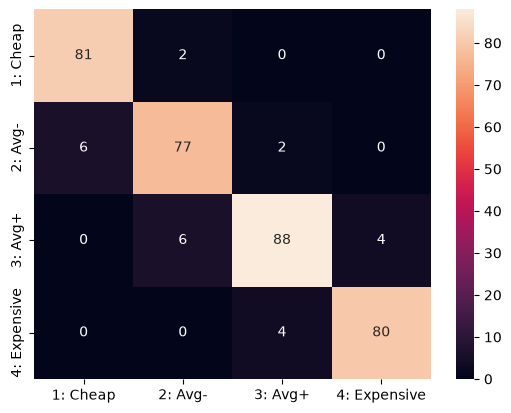

In [30]:
# confusion matrix
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g',
            xticklabels=categories, yticklabels=categories)

In [31]:
# print the classification report based on true values and predictions
print(classification_report(y_test, test_predictions, target_names=categories))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

    1: Cheap       0.93      0.98      0.95        83
     2: Avg-       0.91      0.91      0.91        85
     3: Avg+       0.94      0.90      0.92        98
4: Expensive       0.95      0.95      0.95        84

    accuracy                           0.93       350
   macro avg       0.93      0.93      0.93       350
weighted avg       0.93      0.93      0.93       350


Model overall accuracy: 93.14%


In [32]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary classification, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multi category classification , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# get ROC-AUC -score
roc_auc_score(y, model.predict(X), multi_class="ovr")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step


0.9945303333333333

### Try the model in practice with new data

In [33]:
X.columns

Index(['battery_power', 'fc', 'int_memory', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time'],
      dtype='str')

In [34]:
df.head(3)

,battery_power,fc,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,price_range
0,842,1,7,188,2,2,20,756,2549,9,7,19,2: Avg-
1,1021,0,53,136,3,6,905,1988,2631,17,3,7,3: Avg+
2,563,2,41,145,5,6,1263,1716,2603,11,2,9,3: Avg+


In [35]:
# let's try with some imaginary data
# modify this as needed regarding your own dataset

tester_row = {
    'battery_power': 1021, 
    'fc': 0, 
    'int_memory': 53, 
    'mobile_wt': 136, 
    'n_cores': 3, 
    'pc': 6,
    'px_height': 905, 
    'px_width': 1988, 
    'ram': 3031, 
    'sc_h': 17, 
    'sc_w': 3, 
    'talk_time': 7 
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])
result = model.predict(tester_row)[0]
result_text = categories[np.argmax(result)]

# switch to decimal representation 
np.set_printoptions(precision=9, suppress=True)

# 0 cheapest, 3 most expensive
print(f"Predicted price range: {result_text}")
print()
print("Probabilities by class:")
print(categories)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted price range: 4: Expensive

Probabilities by class:
['1: Cheap', '2: Avg-', '3: Avg+', '4: Expensive']
[0.          0.000000659 0.17464368  0.82535565 ]
